In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install timm -q

Mounted at /content/drive


In [3]:
# Tạo kaggle.json thủ công
import os, json

os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_creds = {
    "username": "hongnguynhuy1",  # <- điền username Kaggle của bạn
    "key": "KGAT_9c22c75c5489f1ea3896b24cecafe274"  # <- key vừa lấy
}

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)

os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d sriramr/fruits-fresh-and-rotten-for-classification \
    -p /content/data/classification --unzip
!ls /content/data/classification

Dataset URL: https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification
License(s): unknown
Resuming from 67108864 bytes (3778365444 bytes left)...
100% 3.58G/3.58G [00:37<00:00, 100MB/s]

dataset


In [7]:
import os

train_dir = "/content/data/classification/dataset/train"
test_dir  = "/content/data/classification/dataset/test"

classes = os.listdir(train_dir)
print("Classes:", classes)
print("Số class:", len(classes))

for c in classes:
    n = len(os.listdir(os.path.join(train_dir, c)))
    print(f"  {c}: {n} ảnh")

Classes: ['freshoranges', 'freshbanana', 'rottenoranges', 'rottenapples', 'rottenbanana', 'freshapples']
Số class: 6
  freshoranges: 1466 ảnh
  freshbanana: 1581 ảnh
  rottenoranges: 1595 ảnh
  rottenapples: 2342 ảnh
  rottenbanana: 2224 ảnh
  freshapples: 1693 ảnh


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm
from tqdm import tqdm
import json, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [9]:
train_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [10]:
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset   = ImageFolder(test_dir,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

CLASS_NAMES = train_dataset.classes
print("Classes:", CLASS_NAMES)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Train: 10901 | Val: 2698


In [12]:
class FruitQualityClassifier(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnetv2_s",
            pretrained=False, # Changed from True to False
            num_classes=0,
            global_pool="avg"
        )
        feature_dim = self.backbone.num_features  # 1280

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))

model = FruitQualityClassifier(num_classes=6).to(DEVICE)
print(model)

FruitQualityClassifier(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): ConvBnAct(
          (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNormAct2d(
            24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (drop_path): Identity()
        )
        (1): ConvBnAct(
          (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNormAct2d(
            24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identi

In [14]:
import os
os.makedirs("/content/drive/MyDrive/agri_weights", exist_ok=True)
print("✅ Folder created!")

✅ Folder created!


In [15]:
NUM_EPOCHS = 10
LR         = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_acc = 0.0

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} Train"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validate
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} Val"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            out  = model(images)
            val_loss += criterion(out, labels).item()
            _, pred = out.max(1)
            correct += pred.eq(labels).sum().item()
            total   += labels.size(0)

    acc = 100.0 * correct / total
    scheduler.step()

    tl = train_loss / len(train_loader)
    vl = val_loss   / len(val_loader)
    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["val_acc"].append(acc)

    print(f"Epoch {epoch+1}: Train Loss={tl:.4f} | Val Loss={vl:.4f} | Val Acc={acc:.2f}%")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/agri_weights/efficientnet_best.pth")
        print(f"  💾 Saved! Best acc={acc:.2f}%")

print(f"\n✅ Done! Best Val Acc: {best_acc:.2f}%")

Epoch 1/10 Val: 100%|██████████| 85/85 [00:32<00:00,  2.60it/s]


Epoch 1: Train Loss=0.7224 | Val Loss=0.5857 | Val Acc=92.74%
  💾 Saved! Best acc=92.74%


Epoch 2/10 Val: 100%|██████████| 85/85 [00:33<00:00,  2.51it/s]


Epoch 2: Train Loss=0.6520 | Val Loss=0.5432 | Val Acc=94.77%
  💾 Saved! Best acc=94.77%


Epoch 3/10 Val: 100%|██████████| 85/85 [00:33<00:00,  2.55it/s]


...

Epoch 8: Train Loss=0.4733 | Val Loss=0.4444 | Val Acc=99.18%
  💾 Saved! Best acc=99.18%


Epoch 9/10 Val: 100%|██████████| 85/85 [00:31<00:00,  2.67it/s]


Epoch 9: Train Loss=0.4655 | Val Loss=0.4368 | Val Acc=99.37%
  💾 Saved! Best acc=99.37%


Epoch 10/10 Val: 100%|██████████| 85/85 [00:32<00:00,  2.63it/s]


Epoch 10: Train Loss=0.4605 | Val Loss=0.4365 | Val Acc=99.41%
  💾 Saved! Best acc=99.41%

✅ Done! Best Val Acc: 99.41%


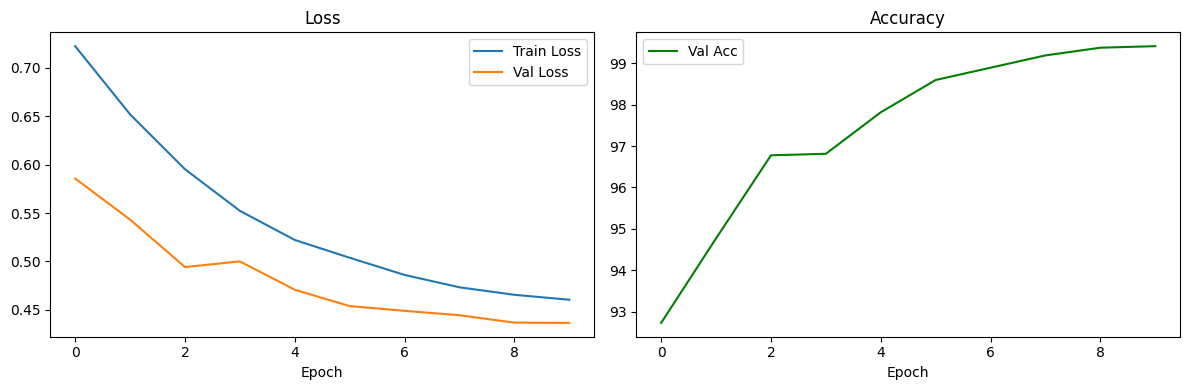

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"],   label="Val Loss")
ax1.set_title("Loss"); ax1.legend(); ax1.set_xlabel("Epoch")

ax2.plot(history["val_acc"], label="Val Acc", color="green")
ax2.set_title("Accuracy"); ax2.legend(); ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/agri_weights/training_curve.png")
plt.show()

               precision    recall  f1-score   support

  freshapples       0.98      0.99      0.99       395
  freshbanana       1.00      1.00      1.00       381
 freshoranges       0.99      0.99      0.99       388
 rottenapples       0.99      0.99      0.99       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       0.99      1.00      0.99       403

     accuracy                           0.99      2698
    macro avg       0.99      0.99      0.99      2698
 weighted avg       0.99      0.99      0.99      2698



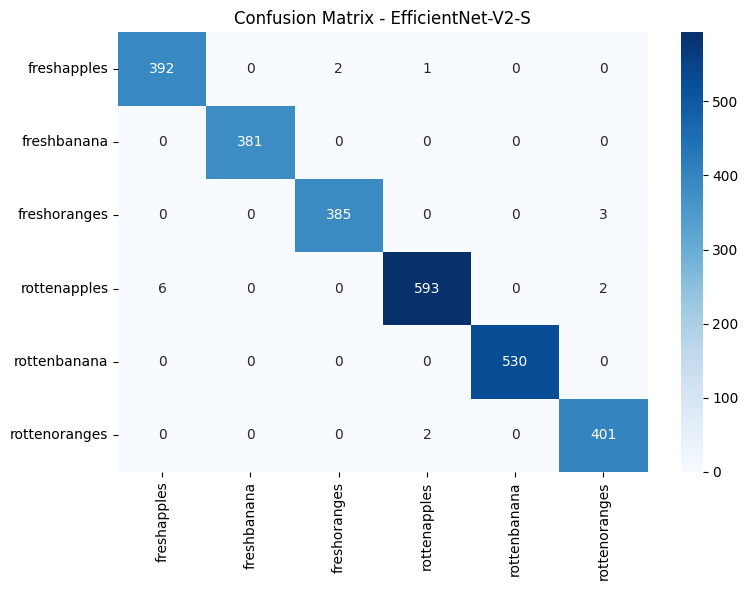

In [17]:
model.load_state_dict(torch.load("/content/drive/MyDrive/agri_weights/efficientnet_best.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        _, preds = model(images).max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
plt.title("Confusion Matrix - EfficientNet-V2-S")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/agri_weights/confusion_matrix.png")
plt.show()